**Papers i like**
https://arxiv.org/pdf/2002.09116
https://proceedings.neurips.cc/paper_files/paper/2015/file/eb1e78328c46506b46a4ac4a1e378b91-Paper.pdf

**https://arxiv.org/html/2505.16082v1**


**https://www.imperial.ac.uk/media/imperial-college/faculty-of-natural-sciences/department-of-mathematics/math-finance/239236448---Hugo-Ng---Ng_Hugo_01848839.pdf**

A vague idea of what I had in mind when I first proposed this project:
 
1. Decide on some selection of changepoints. An example set may be, gaussian change in mean, gaussian change in variance, gaussian change to some heavier tailed distribution (and many else, if you want to). There are also options for going from 1 dimension to higher dimensions. 
2. For each change, design a correctly specified parametric detector, using cost functions designed to look for the changes we are actually searching for. Get the type of power graphs we have been talking about from these. 
3. Now, try and detect the same changes with kernel based methods. 
	(the following questions may seem a bit boring, and in all honesty they might be. However they are genuinely important to have a good answer to. I currently do not have good answers to all of them)
	a. how should each detector be set up? What is the null hypothesis we are supposing, hence how should we tune the threshold beta? 
	b. how should we pick the length scale? Re run the tuning on every sample? what about if we fix it beforehand whilst we are doing monte carlo sim to get some false positive rate. 
4. Compare multiple kernels to one another. Does one capture changes in tail behaviour noticeable easier? do some work better for different types of change? e.g., for gaussian change in mean perhaps rbf is best, but for lorentzian change in mean, maybe a different kernel does better. 
5. (optional) is there any theory we can do to support any conclusions we find in step 4?
 




 

In [1]:
from AMOC_Detector import Detector, gaussian_mean_change, rbf_kernel, median_heuristic, Laplacian_kernel, gaussian_variance_change
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from scipy.stats import cauchy
from functools import partial
from numpy.typing import NDArray



***Some changes we will work with***

In [2]:
def mean_change(ts, changepoint: int, delta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    ts_new[changepoint:] += delta
    return ts_new

def variance_change(ts, changepoint: int, delta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    ts_new[changepoint:] *= delta
    return ts_new


def shape_change(ts, changepoint: int, delta: float, beta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    ts_new[changepoint:] = ts_new[changepoint:] * delta + beta
    return ts_new


def cauchy_change(ts, changepoint: int, delta: float, beta: float, **kwargs) -> np.ndarray:
    ts_new = ts.copy()
    tail_shape = ts_new[changepoint:].shape
    ts_new[changepoint:] = ts_new[changepoint:] + cauchy.rvs(loc=delta, scale=beta, size=tail_shape)
    return ts_new



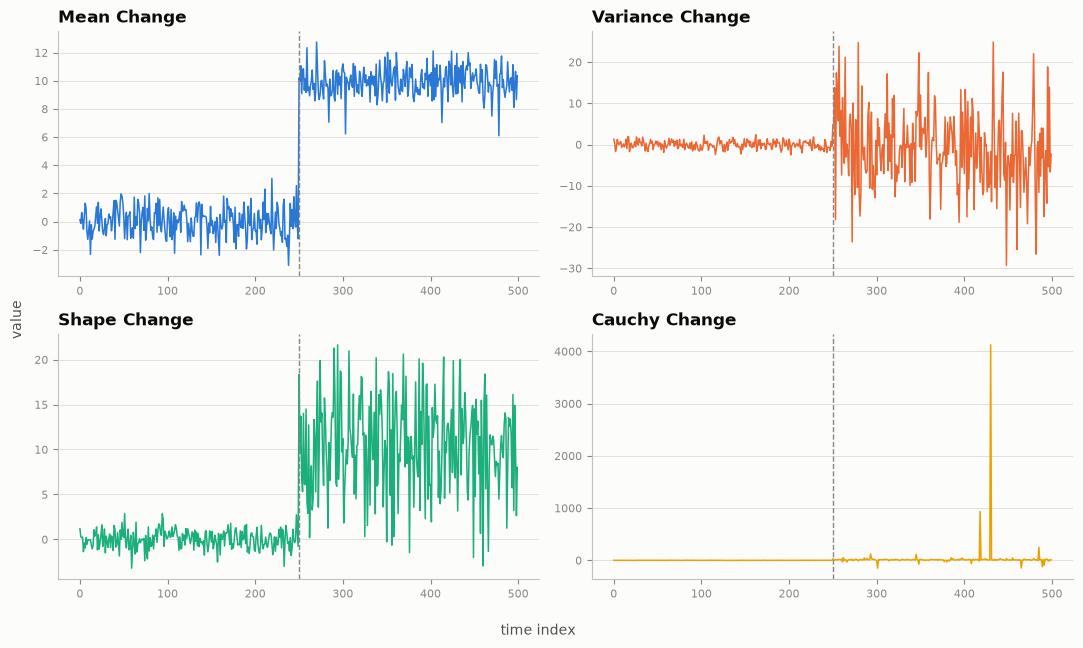

In [3]:

colors = {
    "mean_change": "#2a78d6",      # blue
    "variance_change": "#eb6834",  # orange
    "shape_change": "#1baf7a",     # aqua
    "cauchy_change": "#eda100",    # yellow
}

fns = {
    "mean_change": lambda ts, cp: mean_change(ts, cp, delta=10),
    "variance_change": lambda ts, cp: variance_change(ts, cp, delta=10),
    "shape_change": lambda ts, cp: shape_change(ts, cp, delta=5, beta=10),
    "cauchy_change": lambda ts, cp: cauchy_change(ts, cp, delta=10, beta=5),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
fig.patch.set_facecolor("#fcfcfb")
rng = np.random.default_rng(0)

for ax, (name, fn) in zip(axes.flat, fns.items()):
    ts = rng.multivariate_normal(mean=np.zeros(1), cov=np.eye(1), size=500)
    changepoint = 250
    ts_shifted = fn(ts, changepoint)

    ax.plot(ts_shifted[:, 0], color=colors[name], linewidth=1.1)
    ax.axvline(changepoint, color="#898781", linestyle="--", linewidth=1)

    ax.set_facecolor("#fcfcfb")
    ax.set_title(name.replace("_", " ").title(), color="#0b0b0b", fontsize=12, fontweight="bold", loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors="#898781", labelsize=8)
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.7)
    ax.set_axisbelow(True)

fig.supxlabel("time index", color="#52514e", fontsize=10)
fig.supylabel("value", color="#52514e", fontsize=10)
fig.tight_layout()
plt.show()


This is a very basic function for beta tuning our values using using MC methods to find the 0.05 percentile

In [4]:
def beta_tuning(alpha, cost_function, dim, n=500) -> float:
    maxima = []
    for i in range(1000):
        ts = np.random.multivariate_normal(mean=np.ones(dim), cov=np.eye(dim), size=n)
        maxima.append(np.max(cost_function(ts)))
    return float(np.quantile(maxima, 1 - alpha))



Our benchmark that we will be using is an oracle statistic, this works simply by allowing our test to have the full information and the change point to create the optimal segmentation for our Cusum Statistic, this seems counter intutive but the only time we will reject it, it will 

In [ ]:
def oracle_statistic_mean(timeseries: NDArray, t: int) -> float:
    x = np.asarray(timeseries, dtype=float).reshape(len(timeseries), -1)
    n = len(timeseries)
    return(gaussian_mean_change(x))

def oracle_statistic_var(timeseries: NDArray, t:int) -> float:
    x = np.asarray(timeseries,dtype=float).reshape(len(timeseries),-1)
    n = len(timeseries)
    return gaussian_variance_change(x)

def oracle_beta_tuning(alpha, dim, n=500) -> float:
    stats = []
    for i in range(1000):
        ts = np.random.multivariate_normal(mean=np.ones(dim), cov=np.eye(dim), size=n)
        cp = int(np.ceil(np.random.uniform(0.05 * n, 0.95 * n) ))
        stats.append(oracle_statistic(timeseries=ts, t=cp))
    return float(np.quantile(stats, 1 - alpha))


In [ ]:
def statistical_test_v1(change_type_fn, delta, alpha, tests, dim, beta=1, n=500, tolerance=1) -> dict:
    #Allows for tuning outside of test, partial is used
    pilot = np.random.multivariate_normal(mean=np.ones(dim), cov=np.eye(dim), size=n)
    length_scale = median_heuristic(pilot)
    rbf_cost_fn = partial(rbf_kernel, length_scale=length_scale)
    laplacian_cost_fn = partial(Laplacian_kernel, length_scale=length_scale)

    gaussian_beta = beta_tuning(alpha, gaussian_mean_change, dim, n=n)
    rbf_beta = beta_tuning(alpha, rbf_cost_fn, dim, n=n)
    laplacian_beta = beta_tuning(alpha, laplacian_cost_fn, dim, n=n)
    oracle_beta = oracle_beta_tuning(alpha, dim, n=n)
    parametric_detector = Detector(cost_function=gaussian_mean_change, penalty=gaussian_beta)
    kernel_detector = Detector(cost_function=rbf_cost_fn, penalty=rbf_beta)
    laplacian_detector = Detector(cost_function=laplacian_cost_fn, penalty=laplacian_beta)
    counts = {"RBF": 0, "Gaussian": 0, "Laplacian": 0, "Oracle": 0}

    for i in range(tests):
        ts = np.random.multivariate_normal(mean=np.ones(dim), cov=np.eye(dim), size=n)
        changepoint = int(np.ceil(np.random.uniform(0.05 * n, 0.95 * n)))
        ts_shifted = change_type_fn(ts, changepoint, delta, beta=beta)

        # Oracle already knows the true changepoint, so it just tests directly
        # at that one point instead of searching/localizing.
        oracle_result = oracle_statistic(timeseries=ts_shifted, t=changepoint)
        if oracle_result >= oracle_beta:
            counts["Oracle"] += 1

        result = parametric_detector.detect(time_series=ts_shifted)
        if result is not None and abs(result[0][0] - changepoint) <= tolerance:
            counts["Gaussian"] += 1

        result = kernel_detector.detect(time_series=ts_shifted)
        if result is not None and abs(result[0][0] - changepoint) <= tolerance:
            counts["RBF"] += 1

        result = laplacian_detector.detect(time_series=ts_shifted)
        if result is not None and abs(result[0][0] - changepoint) <= tolerance:
            counts["Laplacian"] += 1

        

    counts = {k: v / tests for k, v in counts.items()}
    return counts


Here I will optimise my value of tolerance in order to see which value has a high power yet also has a low type 1 error.

In [ ]:
def power(change_type_fn, alpha, tests, dim, beta=1, n=500):
    x = np.linspace(1, 4, 10)   # delta values swept, sample size held fixed at n
    results = {"RBF": [], "Gaussian": [], "Laplacian": [], "Oracle": []}
    for i in x:
        result = statistical_test_v1(change_type_fn=change_type_fn, delta=i, alpha=alpha, tests=tests, dim=dim, beta=beta, n=n)
        results["RBF"].append(result["RBF"])
        results["Gaussian"].append(result["Gaussian"])
        results["Laplacian"].append(result["Laplacian"])
        results["Oracle"].append(result["Oracle"])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor("#fcfcfb")
    ax.set_facecolor("#fcfcfb")

    ax.plot(x, results["Gaussian"], label="Gaussian", color="#2a78d6", linewidth=2, marker="o", markersize=5)
    ax.plot(x, results["RBF"], label="RBF", color="#eb6834", linewidth=2, marker="o", markersize=5)
    ax.plot(x, results["Laplacian"], label="Laplacian", color="#1baf7a", linewidth=2, marker="o", markersize=5)
    ax.plot(x, results["Oracle"], label="Oracle", color="#722873", linewidth=2, marker="o", markersize=5)
    ax.axhline(alpha, color="#898781", linestyle="--", linewidth=1, label=f"alpha = {alpha}")

    ax.set_xlabel("delta", color="#52514e")
    ax.set_ylabel("detection rate", color="#52514e")
    ax.set_title(change_type_fn.__name__.replace("_", " ").title(), color="#0b0b0b", fontsize=13, fontweight="bold", loc="left")
    ax.set_ylim(-0.05, 1.05)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)

    ax.legend(frameon=False, labelcolor="#0b0b0b")
    fig.tight_layout()
    plt.show()

power(change_type_fn=mean_change, alpha=0.05, tests=1000, dim=5)


Power as sample size increases, delta held fixed

/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/

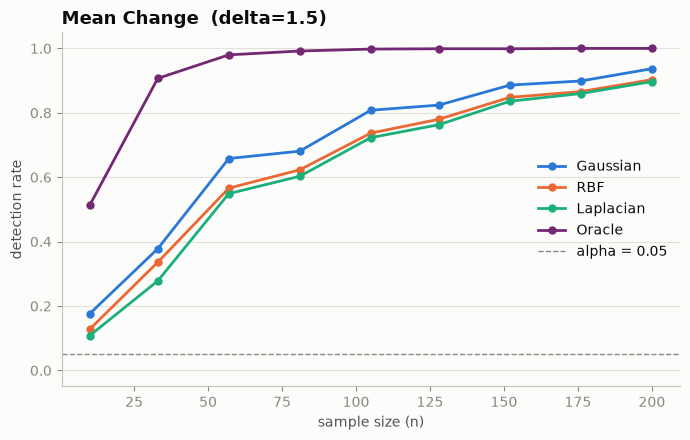

In [50]:
def power_by_sample_size(change_type_fn, alpha, delta, dim, beta=1, tests=1000, sample_sizes=None):
    if sample_sizes is None:
        sample_sizes = np.linspace(10, 200, 9).astype(int)
    results = {"RBF": [], "Gaussian": [], "Laplacian": [], "Oracle": []}

    for i in sample_sizes:
        result = statistical_test_v1(change_type_fn=change_type_fn, delta=delta, alpha=alpha, tests=tests, dim=dim, beta=beta, n=i, tolerance=0.02 * i)
        results["RBF"].append(result["RBF"])
        results["Gaussian"].append(result["Gaussian"])
        results["Laplacian"].append(result["Laplacian"])
        results["Oracle"].append(result["Oracle"])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor("#fcfcfb")
    ax.set_facecolor("#fcfcfb")

    ax.plot(sample_sizes, results["Gaussian"], label="Gaussian", color="#2a78d6", linewidth=2, marker="o", markersize=5)
    ax.plot(sample_sizes, results["RBF"], label="RBF", color="#eb6834", linewidth=2, marker="o", markersize=5)
    ax.plot(sample_sizes, results["Laplacian"], label="Laplacian", color="#1baf7a", linewidth=2, marker="o", markersize=5)
    ax.plot(sample_sizes, results["Oracle"], label="Oracle", color="#722873", linewidth=2, marker="o", markersize=5)
    ax.axhline(alpha, color="#898781", linestyle="--", linewidth=1, label=f"alpha = {alpha}")

    ax.set_xlabel("sample size (n)", color="#52514e")
    ax.set_ylabel("detection rate", color="#52514e")
    ax.set_title(change_type_fn.__name__.replace("_", " ").title() + f"  (delta={delta})",
                 color="#0b0b0b", fontsize=13, fontweight="bold", loc="left")
    ax.set_ylim(-0.05, 1.05)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#c3c2b7")
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors="#898781")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
    ax.set_axisbelow(True)

    ax.legend(frameon=False, labelcolor="#0b0b0b")
    fig.tight_layout()
    plt.show()

power_by_sample_size(change_type_fn=mean_change, alpha=0.05, delta=1.5, dim=1)


/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/1657393229.py:5: RuntimeWarning: invalid value encountered in divide
  left, right = cs[t] / t, (cs[n] - cs[t]) / (n - t)
/var/folders/qj/n5p_8vmx00g6szbh7sytqsdw0000gn/T/ipykernel_33448/

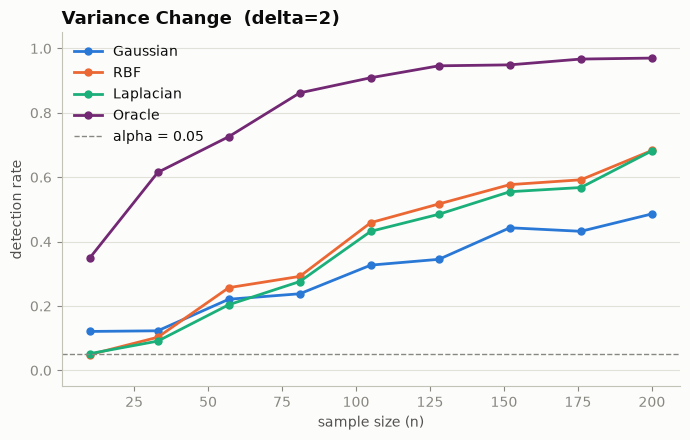

In [47]:
power_by_sample_size(change_type_fn=variance_change, alpha=0.05, delta=2, dim=1)


**Possible ways I could build it further**
1) A oracle test
2) Compare against the Epps-Singleton test, t test, CVM



What is the Laplace Test, this is a centroid test that is a measure of observed arrival times with mid point of the period of observation. This

Possible question:
https://proceedings.neurips.cc/paper_files/paper/2008/file/08b255a5d42b89b0585260b6f2360bdd-Paper.pdf

Length Scales, What are their purpose. Length scales are used in Mathematics in order